In [1]:
%load_ext autoreload

In [2]:
%autoreload 2

In [3]:
from scipy.ndimage import gaussian_filter1d
import matplotlib.pyplot as plt
from pathlib import Path
from main_funcs import *
import nevergrad as ng
import numpy as np

plt.rcParams.update({
    'font.size': 18,
    'axes.titlesize': 22,
    'axes.labelsize': 20,
    'xtick.labelsize': 18,
    'ytick.labelsize': 18,
    'legend.fontsize': 18,
})

In [4]:
base_dirs = {
    "Without": Path("data/Without EDM"),
    "With": Path("data/With EDM"),
    "Without New": Path("data/Without EDM NEW"),
    "With New": Path("data/With EDM NEW")
}

data_all = load_array_data(base_dirs)

In [12]:
def acceptance_func(theta, lambdas, p):
    theta_cut = 20
    mu = 0
    sigma = 15

    if theta.ndim == 2:
        theta_axis = theta[:, 0]
    else:
        theta_axis = theta

    theta_shifted = theta_axis - mu

    top_hat = np.where(np.abs(theta_shifted) <= theta_cut, 1.0, 0.0)

    dtheta = np.abs(theta_axis[1] - theta_axis[0])
    sigma_pix = sigma / dtheta

    acceptance = gaussian_filter1d(top_hat, sigma=sigma_pix, mode="constant", cval=0)

    acceptance /= acceptance.max()

    return p * acceptance[:, None]

In [ ]:
gamma = 29.303431969091314
lam_curr = 0.45

# Reference full coordinate grids
Y_full_ref = data_all["With"][0]["Y"]      # shape (500,500)
X_full_ref = data_all["With"][0]["X"]

X = data_all["With"][0]["X"]
Y = data_all["With"][0]["Y"]
Z = data_all["With"][0]["Z"]

Z = acceptance_func(Y,X,Z)

# Compute θ_max(λ)
theta_max_full = np.arcsin(
    np.sqrt(X_full_ref * (1 - X_full_ref)) / (gamma * X_full_ref)
)

# Convert θ_max from radians → mrad to match Y grid
theta_max_full_mrad = theta_max_full * 1e3

# Build mask using mrad units
physical_mask = np.abs(Y_full_ref) <= theta_max_full_mrad

lam_idx = np.argmin(np.abs(X_full_ref - lam_curr))
lambda_mask = np.zeros_like(X_full_ref)
lambda_mask[:, lam_idx] = 1

physical_mask = np.where(lambda_mask, physical_mask, 0.0)

In [ ]:
p = np.ones_like(X)

# run your acceptance function
A = acceptance_func(Y, X, p)

# acceptance as a function of theta (take one lambda slice)
theta_axis = Y[:,0]
acceptance = A[:,0]

plt.figure(figsize=(8,5))
plt.plot(theta_axis, acceptance, label="Acceptance")
plt.xlabel(r"Longitudinal Angle $\theta$ [mrad]")
plt.ylabel("Acceptance")
plt.title("Detector Acceptance Function")
plt.xlim(-70,70)
plt.ylim(0,1.1)
plt.grid(alpha=0.3)
plt.legend()
plt.tight_layout()
plt.show()

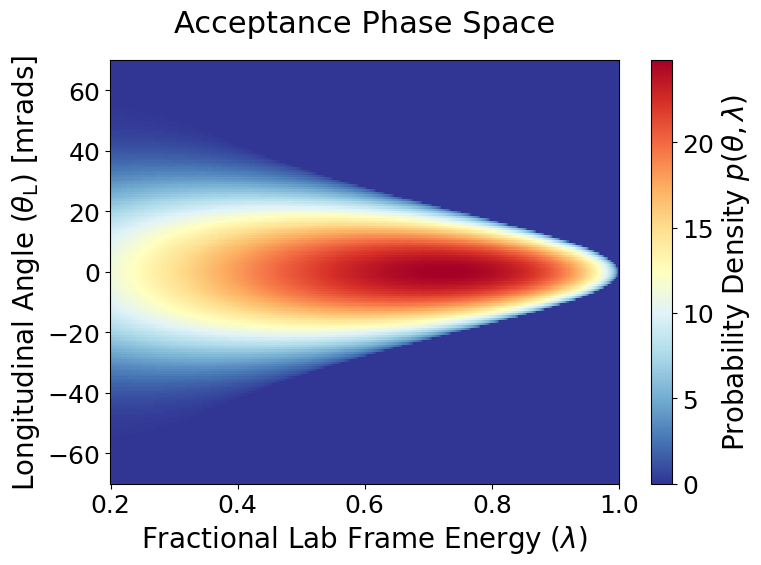

In [ ]:
cmap = plt.get_cmap("RdYlBu_r")
norm = mpl.colors.Normalize(vmin=Z.min(), vmax=Z.max())

fig, ax = plt.subplots(figsize=(8, 6))
ax.pcolormesh(X, Y, Z, shading="auto", cmap="RdYlBu_r")
ax.set_ylim([-70,70])
ax.set_xlabel(r"Fractional Lab Frame Energy ($\lambda$)")
ax.set_ylabel(r"Longitudinal Angle ($\theta_\mathrm{L}$) [mrads]")

sm = mpl.cm.ScalarMappable(norm=norm, cmap=cmap)
sm.set_array([])

fig.colorbar(sm, ax=ax, label=r"Probability Density $p(\theta,\lambda)$")
ax.set_title("Acceptance Phase Space",pad=20)
plt.tight_layout()
plt.show()

In [8]:
# --- CMA-ES configuration ---
grid_size = 500
ny_half = grid_size // 2
num_params = ny_half * grid_size

budget = 300
num_workers = 4

fom_history = []   # store FOM values
iter_history = []  # store iteration numbers

# --- Create or resume optimiser ---
parametrization = ng.p.Array(shape=(num_params,)).set_bounds(0, 10)
optimizer = ng.optimizers.CMA(
    parametrization=parametrization,
    budget=budget,
    num_workers=num_workers,
)

# --- Run optimisation loop with progress tracking ---
for i in range(budget):
    x = optimizer.ask()
    value = objective(data_all, physical_mask, x.value, acceptance_func=acceptance_func)
    optimizer.tell(x, value)

    fom_history.append(-value)     # convert back to positive FOM
    iter_history.append(i + 1)

    # Save checkpoint and progress every few steps
    if (i + 1) % 20 == 0 or i == budget - 1:
        print(f"Iter {i+1}/{budget} | FOM = {fom_history[-1]:.3f}")

# --- Final recommendation ---
# np.savez("HUGE DATA WOW.npz", iter=iter_history, fom=fom_history)
recommendation = optimizer.provide_recommendation()
best_vector = recommendation.value
best_FOM = -objective(data_all, physical_mask, best_vector)
print(f"\nOptimisation finished.\nBest FOM = {best_FOM:.4f}")

Iter 20/300 | FOM = 197.059
Iter 40/300 | FOM = 196.677
Iter 60/300 | FOM = 207.787
Iter 80/300 | FOM = 206.339
Iter 100/300 | FOM = 219.700
Iter 120/300 | FOM = 214.825
Iter 140/300 | FOM = 226.462


c:\Users\JakeS\AppData\Local\Programs\Python\Python312\Lib\site-packages\cma\sigma_adaptation.py:518: UserWarning: TPA: apparent inconsistency with mirrored samples, where dmi_div_dx0i, dm/dx0=2.985847, -7.246153 and dmi_div_dx1i, dm/dx1=-0.434939, -0.434939 
 i=15703 expected precision=0.000000 mean[i]=0.197988 (time=Mar 16 14:32:02 2026 class=CMAAdaptSigmaTPA method=check_consistency iteration=10)
  'CMAAdaptSigmaTPA', es.countiter); m and _warnings.warn(m)


Iter 160/300 | FOM = 231.246
Iter 180/300 | FOM = 233.901
Iter 200/300 | FOM = 254.932
Iter 220/300 | FOM = 246.208
Iter 240/300 | FOM = 251.522
Iter 260/300 | FOM = 247.826
Iter 280/300 | FOM = 255.008


c:\Users\JakeS\AppData\Local\Programs\Python\Python312\Lib\site-packages\cma\sigma_adaptation.py:518: UserWarning: TPA: apparent inconsistency with mirrored samples, where dmi_div_dx0i, dm/dx0=0.448977, 0.756726 and dmi_div_dx1i, dm/dx1=-0.448977, -0.448977 
 i=122714 expected precision=0.000000 mean[i]=1.050253 (time=Mar 16 15:00:48 2026 class=CMAAdaptSigmaTPA method=check_consistency iteration=20)
  'CMAAdaptSigmaTPA', es.countiter); m and _warnings.warn(m)


Iter 300/300 | FOM = 259.271

Optimisation finished.
Best FOM = 744.2467


In [9]:
# --- Rebuild the best weight grids (symmetric θ version) ---
ny_half = grid_size // 2
nx = grid_size

# reshape the optimised half-θ grid
best_half = best_vector.reshape((ny_half, nx))
best_half = np.clip(best_half, 0, None)

# mirror it vertically to enforce θ symmetry
best_coarse = np.vstack([np.flipud(best_half), best_half])

# upscale and apply same processing as in objective
best_full = expand_weight_grid(best_coarse)
best_full = gaussian_filter(best_full, sigma=2)
best_full = np.where(physical_mask, best_full, 0)
best_full = acceptance_func(Y, X, best_full)

outname = "acceptance_func/Strong Resolution Smearing.npz"
np.savez(outname, weight=best_full, lam=lam_curr, budget=budget)

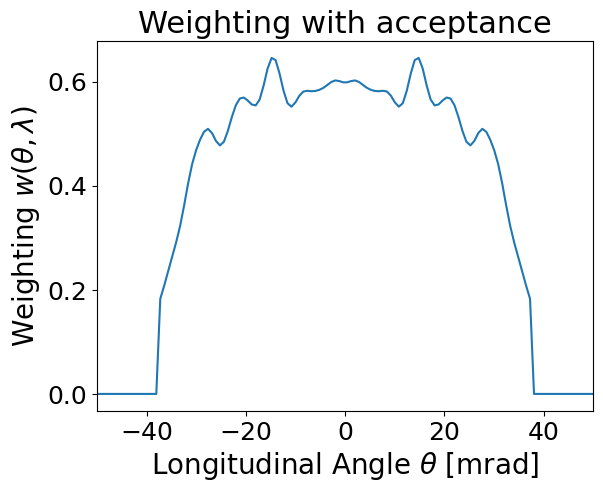

In [10]:
w_cma = np.load("C:/Users/JakeS/Documents/Masters Project/mphys-masters-project/Weight_Maps2/optimal_weight_lam=0.45_budget=2040.npz", allow_pickle=True)["weight"]

plt.plot(Y[:,lam_idx],best_full[:,lam_idx],label="Acceptance")
# plt.plot(Y[:,lam_idx],w_cma["weight"][:,lam_idx],label="Full")
plt.xlabel(r"Longitudinal Angle $\theta$ [mrad]")
plt.ylabel(r"Weighting $w(\theta,\lambda)$")
# plt.legend()
plt.xlim([-50,50])
plt.title("Weighting with acceptance")
plt.show()

In [11]:
fom_curr = compute_fom_for_lambda(data_all, 1e5, 0.45, weight_func=lambda Y, X: best_full)
fom_cma = compute_fom_for_lambda(data_all,1e5,0.45, weight_func=lambda Y,X: w_cma)

print(f"{fom_curr["FOM"]/fom_cma["FOM"]:.3g}")

0.478
